# AIGEFS

In December 2025, NOAA announced the release of three AI global forecasting systems.

[NOAA deploys new generation of AI-driven global weather models](https://www.noaa.gov/news-release/noaa-deploys-new-generation-of-ai-driven-global-weather-models)

All three models are available for download in Herbie:

- `model="aigfs"`

- `model="aigefs"`

- `model="hgefs"`

This notebook demonstrates how to download and use AIGEFS data using Herbie.


In [3]:
from herbie import Herbie
from herbie.toolbox import EasyMap, pc, ccrs
from herbie import paint

import matplotlib.pyplot as plt

There are two available products:

- `product="sfc"`
- `product="pres"`

You must specify the extra argument `member=`. Herbie will tell you the list of valid members...


In [4]:
H = Herbie("2026-02-01", model="aigefs", product="sfc", member="what?")
H

ValueError: For AIGEFS product sfc, member must be one of ['mem000', 'mem001', 'mem002', 'mem003', 'mem004', 'mem005', 'mem006', 'mem007', 'mem008', 'mem009', 'mem010', 'mem011', 'mem012', 'mem013', 'mem014', 'mem015', 'mem016', 'mem017', 'mem018', 'mem019', 'mem020', 'mem021', 'mem022', 'mem023', 'mem024', 'mem025', 'mem026', 'mem027', 'mem028', 'mem029', 'mem030', 'control', 'spr', 'avg']

Let's get the ensemble mean...


In [5]:
H = Herbie("2026-02-01", model="aigefs", product="sfc", member="avg")
H


✅ Found ┊ model=aigefs ┊ product=sfc ┊ 2026-Feb-01 00:00 UTC F00 ┊ GRIB2 @ nomads ┊ IDX @ local


▌▌Herbie AIGEFS model sfc product initialized 2026-Feb-01 00:00 UTC F00 ┊ source=nomads

In [6]:
# Show all available sources
H.SOURCES

{'nomads': 'https://nomads.ncep.noaa.gov/pub/data/nccf/com/aigefs/prod/aigefs.20260201/00/ensstat/products/atmos/grib2/aigefs.t00z.sfc.avg.f000.grib2'}

In [7]:
H.inventory()

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,?,search_this
0,1,0,860132.0,0-860132,2026-02-01,2026-02-01,UGRD,10 m above ground,anl,ens mean,:UGRD:10 m above ground:anl:ens mean:
1,2,860133,1680784.0,860133-1680784,2026-02-01,2026-02-01,VGRD,10 m above ground,anl,ens mean,:VGRD:10 m above ground:anl:ens mean:
2,3,1680785,2132284.0,1680785-2132284,2026-02-01,2026-02-01,TMP,2 m above ground,anl,ens mean,:TMP:2 m above ground:anl:ens mean:
3,4,2132285,NaN,2132285-,2026-02-01,2026-02-01,PRMSL,mean sea level,anl,ens mean,:PRMSL:mean sea level:anl:ens mean:


Now, let's look at the 1st member for the pressure fields...


In [8]:
H = Herbie("2026-02-01", model="aigefs", product="pres", member="mem001")
H.inventory()


✅ Found ┊ model=aigefs ┊ product=pres ┊ 2026-Feb-01 00:00 UTC F00 ┊ GRIB2 @ nomads ┊ IDX @ nomads


,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,?,search_this
0,1,0,654388.0,0-654388,2026-02-01,2026-02-01,HGT,50 mb,anl,P-ENS=1,:HGT:50 mb:anl:P-ENS=1:
1,2,654389,1301679.0,654389-1301679,2026-02-01,2026-02-01,HGT,100 mb,anl,P-ENS=1,:HGT:100 mb:anl:P-ENS=1:
2,3,1301680,1945841.0,1301680-1945841,2026-02-01,2026-02-01,HGT,150 mb,anl,P-ENS=1,:HGT:150 mb:anl:P-ENS=1:
3,4,1945842,2584759.0,1945842-2584759,2026-02-01,2026-02-01,HGT,200 mb,anl,P-ENS=1,:HGT:200 mb:anl:P-ENS=1:
4,5,2584760,3214315.0,2584760-3214315,2026-02-01,2026-02-01,HGT,250 mb,anl,P-ENS=1,:HGT:250 mb:anl:P-ENS=1:
...,...,...,...,...,...,...,...,...,...,...,...
73,74,73796507,74454217.0,73796507-74454217,2026-02-01,2026-02-01,VVEL,600 mb,anl,P-ENS=1,:VVEL:600 mb:anl:P-ENS=1:
74,75,74454218,75121374.0,74454218-75121374,2026-02-01,2026-02-01,VVEL,700 mb,anl,P-ENS=1,:VVEL:700 mb:anl:P-ENS=1:
75,76,75121375,75807680.0,75121375-75807680,2026-02-01,2026-02-01,VVEL,850 mb,anl,P-ENS=1,:VVEL:850 mb:anl:P-ENS=1:
76,77,75807681,76460214.0,75807681-76460214,2026-02-01,2026-02-01,VVEL,925 mb,anl,P-ENS=1,:VVEL:925 mb:anl:P-ENS=1:


In [9]:
ds = H.xarray(":TMP:700 mb")
ds

<xarray.Dataset> Size: 4MB
Dimensions:              (latitude: 721, longitude: 1440)
Coordinates:
  * latitude             (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude            (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
    number               int64 8B 1
    time                 datetime64[ns] 8B 2026-02-01
    step                 timedelta64[ns] 8B 00:00:00
    isobaricInhPa        float64 8B 700.0
    valid_time           datetime64[ns] 8B 2026-02-01
    gribfile_projection  object 8B None
Data variables:
    t                    (latitude, longitude) float32 4MB 243.6 243.6 ... 242.5
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   aigefs
    product:                 pres
    description:             AI Global Ensemble Forecast System (AIGEFS)
    remote_grib:             https://nomads.ncep.noaa.gov/pub/data/nccf/com/a...
    local_grib:              /home/blaylock/data/aigefs/20260201/subset_afef7...
    search:                  :TMP:700 mb

Text(0.0, 1.0, 'AIGEFS: pressure fields, 0.25 degree resolution')

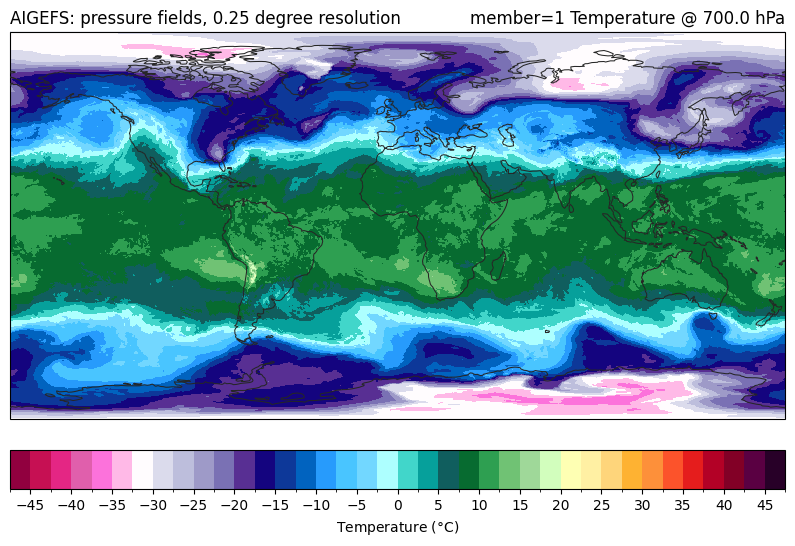

In [10]:
ax = EasyMap(crs=ds.herbie.crs, figsize=[10, 8]).ax
p = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    ds.t - 273.15,
    transform=pc,
    **paint.NWSTemperature.kwargs2,
)
plt.colorbar(
    p, ax=ax, orientation="horizontal", pad=0.05, **paint.NWSTemperature.cbar_kwargs2
)

ax.set_title(
    f"member={ds.number.item()} {ds.t.GRIB_name} @ {ds.t.isobaricInhPa.item()} hPa",
    loc="right",
)
ax.set_title(f"{ds.model.upper()}: {H.product_description}", loc="left")

Now, just for fun, let's plot the difference between member 1 and the ensemble average for the 24 hour forecast...


✅ Found ┊ model=aigefs ┊ product=pres ┊ 2026-Feb-01 00:00 UTC F24 ┊ GRIB2 @ nomads ┊ IDX @ nomads
✅ Found ┊ model=aigefs ┊ product=pres ┊ 2026-Feb-01 00:00 UTC F24 ┊ GRIB2 @ nomads ┊ IDX @ local


Text(0.5, 1.0, 'Difference between Member 1 and Ensemble Mean')

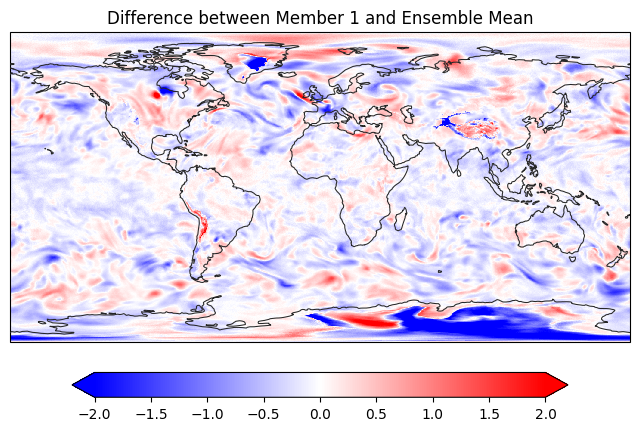

In [11]:
H1 = Herbie("2026-02-01", model="aigefs", product="pres", member="mem001", fxx=24)
H2 = Herbie("2026-02-01", model="aigefs", product="pres", member="avg", fxx=24)

diff = H2.xarray("TMP:700 mb").t - H1.xarray("TMP:700 mb").t

ax = EasyMap(figsize=[8, 8]).ax
p = ax.pcolormesh(
    diff.longitude,
    diff.latitude,
    diff,
    transform=pc,
    vmax=2,
    vmin=-2,
    cmap="bwr",
)

plt.colorbar(
    p,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    shrink=0.8,
    extend="both",
)

plt.title("Difference between Member 1 and Ensemble Mean")